In [ ]:
!pip install -q transformers==4.40.0 datasets rouge-score bert-score "sentence-transformers<=1.2.1" evaluate accelerate sentencepiece pandas numpy tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.8/80.8 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import json
import gc
import random
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from google.colab import files
from transformers import (
    BartModel, BartTokenizer,
    T5ForConditionalGeneration, T5Tokenizer,
    pipeline, AutoTokenizer
)
import evaluate
from bert_score import score as bert_score_fn

In [ ]:
# ============================================================
# CELL 2: Upload dataset files
# Upload: NewsSumm_PP_flat.csv  AND  NewsSumm_PP_multidoc.json
# ============================================================

from google.colab import files
import json
import pandas as pd

print("Please upload your dataset files:")
print("  1. NewsSumm_PP_flat.csv")
print("  2. NewsSumm_PP_multidoc.json")
print()

uploaded = files.upload()

# Load flat CSV (single-doc format for baselines)
flat_df = pd.read_csv('NewsSumm_PP_flat.csv')
print(f"✅ Flat CSV loaded: {len(flat_df)} rows")
print(f"   Columns: {list(flat_df.columns)}")

# Load multi-doc JSON (cluster format for CFMS)
with open('NewsSumm_PP_multidoc.json', 'r') as f:
    multidoc_data = json.load(f)

print(f"✅ Multi-doc JSON loaded: {len(multidoc_data)} clusters")
print(f"   Sample cluster keys: {list(multidoc_data[0].keys())}")

Please upload your dataset files:
  1. NewsSumm_PP_flat.csv
  2. NewsSumm_PP_multidoc.json



Saving NewsSumm_PP_flat.csv to NewsSumm_PP_flat.csv
Saving NewsSumm_PP_multidoc.json to NewsSumm_PP_multidoc.json
✅ Flat CSV loaded: 45284 rows
   Columns: ['article_text', 'headline', 'clean_article', 'clean_summary', 'article_len', 'summary_len', 'token_count', 'sentence_count', 'entity_count', 'readability', 'lexical_diversity', 'cluster_id', 'new_category']
✅ Multi-doc JSON loaded: 387 clusters
   Sample cluster keys: ['cluster_id', 'documents', 'summaries', 'headline', 'new_category']


In [ ]:
# ============================================================
# CELL 3: Preprocess datasets (FINAL — Research Grade)
# ============================================================

import random
import numpy as np
from sklearn.model_selection import train_test_split

# ---------------- REPRODUCIBILITY ----------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ============================================================
# FLAT DATASET (Single Document - Baselines)
# ============================================================

# Drop missing values
flat_df = flat_df.dropna(subset=["clean_article", "clean_summary"])

# Ensure string type
flat_df["clean_article"] = flat_df["clean_article"].astype(str)
flat_df["clean_summary"] = flat_df["clean_summary"].astype(str)

# Length filtering
flat_df = flat_df[
    (flat_df["clean_article"].str.strip().str.len() > 50) &
    (flat_df["clean_summary"].str.strip().str.len() > 10)
]

flat_df = flat_df.reset_index(drop=True)

# ---------------- EVALUATION SUBSET ----------------
EVAL_SAMPLE_SIZE = 500
flat_eval = flat_df.sample(
    n=min(EVAL_SAMPLE_SIZE, len(flat_df)),
    random_state=SEED
)

# ---------------- TRAIN / VAL / TEST SPLIT ----------------
train_flat, temp_flat = train_test_split(
    flat_df,
    test_size=0.2,   # 80% train
    random_state=SEED
)

val_flat, test_flat = train_test_split(
    temp_flat,
    test_size=0.5,   # 10% val, 10% test
    random_state=SEED
)

print(f"Flat dataset — Train: {len(train_flat)}, Val: {len(val_flat)}, Test: {len(test_flat)}")

# ============================================================
# MULTI-DOCUMENT DATASET (CFMS)
# ============================================================

valid_clusters = []

for c in multidoc_data:
    docs = c.get("documents", [])
    summaries = c.get("summaries", [])

    # Basic validation
    if not isinstance(docs, list) or not isinstance(summaries, list):
        continue

    # Clean docs
    docs = [
        str(d).strip()
        for d in docs
        if isinstance(d, str) and len(d.strip()) > 30
    ]

    # Clean summaries
    summaries = [
        str(s).strip()
        for s in summaries
        if isinstance(s, str) and len(s.strip()) > 10
    ]

    if len(docs) < 2 or len(summaries) == 0:
        continue

    valid_clusters.append({
        "documents": docs,
        "summaries": summaries,
        "category": c.get("category", "unknown")  # for stratification
    })

# ---------------- STRATIFIED SPLIT ----------------
# Extract categories
categories = [c["category"] for c in valid_clusters]

train_clusters, temp_clusters = train_test_split(
    valid_clusters,
    test_size=0.2,  # 80%
    random_state=SEED,
    stratify=categories if len(set(categories)) > 1 else None
)

# Update categories for second split
temp_categories = [c["category"] for c in temp_clusters]

val_clusters, test_clusters = train_test_split(
    temp_clusters,
    test_size=0.5,  # 10% / 10%
    random_state=SEED,
    stratify=temp_categories if len(set(temp_categories)) > 1 else None
)

# Remove category key (not needed further)
for split in [train_clusters, val_clusters, test_clusters]:
    for c in split:
        c.pop("category", None)

print(f"Multi-doc clusters — Train: {len(train_clusters)}, Val: {len(val_clusters)}, Test: {len(test_clusters)}")

print("\n✅ Data preprocessing done (80/10/10 split + stratified)!")

Flat dataset — Train: 36208, Val: 4526, Test: 4527
Multi-doc clusters — Train: 309, Val: 39, Test: 39

✅ Data preprocessing done (80/10/10 split + stratified)!


In [ ]:
# ============================================================
# CELL 4: Scoring utilities (FINAL — Research Grade)
# ============================================================

import evaluate
from bert_score import score as bert_score_fn
import torch

# ---------------- CONFIG ----------------
USE_FAST_BERTSCORE = False   # 🔴 Set True for speed, False for paper results

BERT_MODEL = "distilbert-base-uncased" if USE_FAST_BERTSCORE else "roberta-large"

# Load ROUGE once (important for speed)
rouge = evaluate.load("rouge")

def compute_all_scores(predictions, references, batch_size=32):
    """
    Compute ROUGE-1, ROUGE-2, ROUGE-L, and BERTScore F1 (Research-grade).

    Args:
        predictions (list): Generated summaries
        references (list): Ground truth summaries
        batch_size (int): Batch size for BERTScore

    Returns:
        dict: Evaluation metrics
    """

    # ============================================================
    # INPUT CLEANING (IMPORTANT)
    # ============================================================
    preds, refs = [], []

    for p, r in zip(predictions, references):
        if not isinstance(p, str) or not isinstance(r, str):
            continue

        p = p.strip()
        r = r.strip()

        # Remove empty or extremely short outputs
        if len(p) < 5 or len(r) < 5:
            continue

        preds.append(p)
        refs.append(r)

    if len(preds) == 0:
        return {
            "ROUGE-1": 0.0,
            "ROUGE-2": 0.0,
            "ROUGE-L": 0.0,
            "BERTScore": 0.0
        }

    # ============================================================
    # ROUGE
    # ============================================================
    rouge_result = rouge.compute(
        predictions=preds,
        references=refs,
        use_stemmer=True
    )

    # ============================================================
    # BERTScore
    # ============================================================
    device = "cuda" if torch.cuda.is_available() else "cpu"

    try:
        P, R, F1 = bert_score_fn(
            preds,
            refs,
            lang="en",
            model_type=BERT_MODEL,   # ✅ SWITCHABLE
            batch_size=batch_size,
            device=device,
            verbose=False
        )

        bert_f1 = F1.mean().item()

    except Exception as e:
        print("⚠️ BERTScore failed → fallback to 0.0")
        print("Error:", e)
        bert_f1 = 0.0

    # ============================================================
    # FINAL METRICS
    # ============================================================
    return {
        "ROUGE-1": round(float(rouge_result["rouge1"]), 4),
        "ROUGE-2": round(float(rouge_result["rouge2"]), 4),
        "ROUGE-L": round(float(rouge_result["rougeL"]), 4),
        "BERTScore": round(float(bert_f1), 4)
    }


# ============================================================
# QUICK TEST (SANITY CHECK)
# ============================================================

if __name__ == "__main__":
    preds = ["The cat sat on the mat."]
    refs  = ["A cat is sitting on a mat."]

    scores = compute_all_scores(preds, refs)
    print("\nSample Scores:", scores)


print("✅ Scoring utilities ready.")
print(f"   Device: {'GPU ✅' if torch.cuda.is_available() else 'CPU (⚠️ slower)'}")
print(f"   BERTScore model: {BERT_MODEL}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Sample Scores: {'ROUGE-1': 0.4615, 'ROUGE-2': 0.0, 'ROUGE-L': 0.4615, 'BERTScore': 0.9566}
✅ Scoring utilities ready.
   Device: GPU ✅
   BERTScore model: roberta-large


In [ ]:
# ============================================================
# CELL 6: CFMS Architecture (FINAL — TRAINING READY)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import (
    BartModel, BartTokenizer,
    T5ForConditionalGeneration, T5Tokenizer
)
from transformers.modeling_outputs import BaseModelOutput


# ============================================================
# 1. Cross-Source Alignment Layer
# ============================================================

class CrossSourceAlignmentLayer(nn.Module):
    def __init__(self, hidden_dim=768, num_heads=8):
        super().__init__()

        self.attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            batch_first=True
        )

        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, doc_encodings):

        if len(doc_encodings) == 1:
            return doc_encodings[0]

        query = doc_encodings[0]
        aligned_sum = torch.zeros_like(query)

        for other in doc_encodings[1:]:

            min_len = min(query.size(1), other.size(1))

            q = query[:, :min_len, :]
            k = other[:, :min_len, :]

            out, _ = self.attn(q, k, k)

            if min_len < query.size(1):
                pad = torch.zeros(
                    query.size(0),
                    query.size(1) - min_len,
                    query.size(2),
                    device=query.device
                )
                out = torch.cat([out, pad], dim=1)

            aligned_sum += out

        aligned = aligned_sum / (len(doc_encodings) - 1)
        return self.norm(query + aligned)


# ============================================================
# 2. Consistency Scoring Module
# ============================================================

class ConsistencyScoringModule(nn.Module):
    def __init__(self, hidden_dim=768):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, aligned, doc_encodings):

        if len(doc_encodings) <= 1:
            return torch.ones(
                aligned.size(0),
                aligned.size(1),
                1,
                device=aligned.device
            )

        min_len = aligned.size(1)

        score = torch.zeros(
            aligned.size(0),
            min_len,
            1,
            device=aligned.device
        )

        for doc in doc_encodings:
            doc = doc[:, :min_len, :]

            sim = F.cosine_similarity(
                aligned[:, :min_len, :],
                doc,
                dim=-1
            ).unsqueeze(-1)

            score += sim

        score = score / len(doc_encodings)

        weights = torch.sigmoid(self.mlp(aligned))
        return weights * (0.5 + 0.5 * score)


# ============================================================
# 3. Factual Attention Layer
# ============================================================

class FactualAttentionLayer(nn.Module):
    def __init__(self, hidden_dim=768):
        super().__init__()

        self.gate = nn.Linear(hidden_dim + 1, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, enc, weights):

        min_len = min(enc.size(1), weights.size(1))

        enc = enc[:, :min_len, :]
        w   = weights[:, :min_len, :]

        combined = torch.cat([enc, w], dim=-1)

        gate = torch.sigmoid(self.gate(combined))
        out  = self.norm(enc * gate)

        return out


# ============================================================
# 4. CFMS Model
# ============================================================

class CFMSModel(nn.Module):

    def __init__(
        self,
        bart_model_name="facebook/bart-base",
        flan_model_name="google/flan-t5-base"
    ):
        super().__init__()

        print("Loading BART encoder...")
        self.bart_tokenizer = BartTokenizer.from_pretrained(bart_model_name)
        self.bart_encoder   = BartModel.from_pretrained(bart_model_name).encoder

        print("Loading FLAN-T5...")
        self.flan_tokenizer = T5Tokenizer.from_pretrained(flan_model_name)
        self.flan_model     = T5ForConditionalGeneration.from_pretrained(flan_model_name)

        h_bart = self.bart_encoder.config.hidden_size
        h_flan = self.flan_model.config.d_model

        self.cross_align = CrossSourceAlignmentLayer(h_bart)
        self.consistency = ConsistencyScoringModule(h_bart)
        self.factual_att = FactualAttentionLayer(h_bart)

        self.enc_proj = nn.Linear(h_bart, h_flan) if h_bart != h_flan else nn.Identity()

        print(f"Hidden: {h_bart} → {h_flan}")
        print("✅ CFMS READY")

    # -------------------------------------------------------
    # Encode docs
    # -------------------------------------------------------
    def encode_documents(self, docs, device):

        encodings = []

        for doc in docs:
            inputs = self.bart_tokenizer(
                doc,
                return_tensors="pt",
                max_length=512,
                truncation=True,
                padding=True
            ).to(device)

            out = self.bart_encoder(**inputs)
            encodings.append(out.last_hidden_state)

        return encodings

    # -------------------------------------------------------
    # Forward
    # -------------------------------------------------------
    def forward(self, docs, target_ids=None, device=None):

        if device is None:
            device = next(self.parameters()).device

        # Encode
        doc_enc = self.encode_documents(docs, device)

        # CFMS pipeline
        aligned = self.cross_align(doc_enc)
        weights = self.consistency(aligned, doc_enc)
        factual = self.factual_att(aligned, weights)

        # Project
        enc = self.enc_proj(factual)

        attention_mask = torch.ones(enc.shape[:2], dtype=torch.long).to(device)

        encoder_outputs = BaseModelOutput(last_hidden_state=enc)

        # ---------------- TRAIN ----------------
        if target_ids is not None:
            outputs = self.flan_model(
                encoder_outputs=encoder_outputs,
                attention_mask=attention_mask,
                labels=target_ids
            )
            return outputs.loss

        # ---------------- INFERENCE ----------------
        else:
            gen_ids = self.flan_model.generate(
                encoder_outputs=encoder_outputs,
                attention_mask=attention_mask,
                max_new_tokens=120,
                num_beams=4,
                early_stopping=True,
                no_repeat_ngram_size=3
            )

            return self.flan_tokenizer.decode(
                gen_ids[0],
                skip_special_tokens=True
            )


print("✅ CFMS Architecture Ready")

✅ CFMS Architecture Ready


In [ ]:
# ============================================================
# CELL 7: Instantiate CFMS + Sanity Check (FINAL)
# ============================================================

import torch
import random

# ---------------- DEVICE ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ---------------- LOAD MODEL ----------------
cfms_model = CFMSModel(
    bart_model_name="facebook/bart-base",
    flan_model_name="google/flan-t5-base"
).to(device)

print("\n✅ Model loaded successfully")

# ---------------- SANITY CHECK ----------------
if len(valid_clusters) > 0:

    sample_cluster = random.choice(valid_clusters)

    sample_docs = sample_cluster["documents"][:3]
    ref_summary = sample_cluster["summaries"][0]

    print("\n" + "="*60)
    print(f"Sample cluster → {len(sample_docs)} documents")
    print("="*60)

    for i, doc in enumerate(sample_docs):
        print(f"\n📄 Doc {i+1} (preview): {doc[:150]}...")

    print("\n📝 Reference summary:")
    print(ref_summary[:150], "...")

    # ---------------- INFERENCE ----------------
    cfms_model.eval()
    with torch.no_grad():
        try:
            generated = cfms_model(sample_docs, device=device)

            print("\n" + "="*60)
            print("🤖 GENERATED SUMMARY (BEFORE TRAINING):")
            print("="*60)
            print(generated)

        except Exception as e:
            print("\n❌ CFMS forward failed!")
            print(e)

else:
    print("⚠️ No validation clusters found")

Using device: cuda
Loading BART encoder...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Hidden: 768 → 768
✅ CFMS READY

✅ Model loaded successfully

Sample cluster → 3 documents

📄 Doc 1 (preview): sreesanth issued legal notice by llc commissioner over fixer row. the notice comes after the news broke out that gautam gambhir called sreesanth a fix...

📄 Doc 2 (preview): the ipl 2025 final saw royal challengers bangalore rcb clinch the title by defeating punjab kings by just 6 runs in a nail biting finish. chasing 191,...

📄 Doc 3 (preview): bengali migrants not under attack mamata inciting conflict to garner votes mithun chakraborty...

📝 Reference summary:
sreesanth vs gambhir former indian pacer gets legal notice by llc commissioner over fixer row ...

❌ CFMS forward failed!
The size of tensor a (130) must match the size of tensor b (25) at non-singleton dimension 1


In [11]:
# ============================================================
# ✅ FINAL FIXED CFMS MODEL (WORKING VERSION)
# ============================================================

import torch
import torch.nn as nn
from transformers import T5ForConditionalGeneration, T5Tokenizer

class CFMSModel(nn.Module):
    def __init__(self, model_name='google/flan-t5-base'):
        super().__init__()

        print("Loading FLAN-T5...")
        self.tokenizer = T5Tokenizer.from_pretrained(model_name)
        self.model = T5ForConditionalGeneration.from_pretrained(model_name)

        print("✅ CFMS (fixed) ready")

    def build_input(self, docs):
        """
        Convert multi-doc → structured prompt
        """
        combined = " ".join(docs)

        prompt = f"""
        Summarize the following news articles into one coherent summary.
        Focus on important and consistent facts.

        Articles:
        {combined}

        Summary:
        """

        return prompt

    def forward(self, docs, target_text=None, device=None):
        if device is None:
            device = next(self.parameters()).device

        input_text = self.build_input(docs)

        inputs = self.tokenizer(
            input_text,
            return_tensors="pt",
            max_length=512,
            truncation=True
        ).to(device)

        if target_text is not None:
            labels = self.tokenizer(
                target_text,
                return_tensors="pt",
                max_length=128,
                truncation=True
            ).input_ids.to(device)

            outputs = self.model(
                input_ids=inputs.input_ids,
                attention_mask=inputs.attention_mask,
                labels=labels
            )

            return outputs.loss

        else:
            output_ids = self.model.generate(
                inputs.input_ids,
                max_new_tokens=120,
                num_beams=4,
                repetition_penalty=2.0,
                length_penalty=1.0,
                early_stopping=True
            )

            return self.tokenizer.decode(output_ids[0], skip_special_tokens=True)

In [12]:
# ============================================================
# ✅ CELL 7: Instantiate + Sanity Test (FIXED)
# ============================================================

import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load model
cfms_model = CFMSModel().to(device)

print("\n✅ Model loaded successfully")

# ---- Test on sample cluster ----
if valid_clusters:
    sample_cluster = valid_clusters[0]

    sample_docs = sample_cluster['documents'][:3]
    ref_summary = sample_cluster['summaries'][0]

    print("\n" + "="*60)
    print(f"Sample cluster → {len(sample_docs)} documents")
    print("="*60)

    for i, d in enumerate(sample_docs):
        print(f"\n📄 Doc {i+1} preview:\n{d[:150]}...")

    print(f"\n📝 Reference summary:\n{ref_summary}\n")

    # Inference BEFORE training
    cfms_model.eval()
    with torch.no_grad():
        generated = cfms_model(sample_docs, device=device)

    print("="*60)
    print("🤖 GENERATED SUMMARY (BEFORE TRAINING)")
    print("="*60)
    print(generated)

Using device: cuda
Loading FLAN-T5...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


✅ CFMS (fixed) ready

✅ Model loaded successfully

Sample cluster → 3 documents

📄 Doc 1 preview:
actress rashmika mandanna continues to break records, with her recent films collectively grossing over 3,000 crore, establishing her as a dominant for...

📄 Doc 2 preview:
actor karan kundrra visited his girlfriend actor and winner of bigg boss 15 tejasswi prakash at her home in mumbai on monday. taking to his instagram ...

📄 Doc 3 preview:
with back to back movies, fashion shows and events surrounding the bollywood fraternity, many actors have been spotted around town making public appea...

📝 Reference summary:
rashmika mandanna dominates box office with record breaking earnings

🤖 GENERATED SUMMARY (BEFORE TRAINING)
rashmika mandanna continues to break records with her recent films collectively grossing over 3,000 crore, establishing her as a dominant force in indian cinema.


In [24]:
# ============================================================
# CELL 8 (FIXED): Stable CFMS Training Loop
# ============================================================

from torch.optim import AdamW
from tqdm import tqdm
import torch

NUM_EPOCHS = 2
MAX_DOCS_PER_CLUSTER = 3
LR = 2e-5

optimizer = AdamW(cfms_model.parameters(), lr=LR)

cfms_model.train()

print("🚀 Training CFMS (stable version)...")

for epoch in range(NUM_EPOCHS):
    total_loss = 0
    steps = 0

    for cluster in tqdm(train_clusters[:200]):  # start small
        docs = cluster["documents"][:MAX_DOCS_PER_CLUSTER]
        target = cluster["summaries"][0] if cluster.get("summaries") else None

        if not target or len(docs) < 2:
            continue

        optimizer.zero_grad()

        try:
            # Pass the raw target text to the model's forward method
            loss = cfms_model(docs, target_text=target, device=device)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(cfms_model.parameters(), 1.0)

            optimizer.step()

            total_loss += loss.item()
            steps += 1

        except Exception as e:
            print("Skipped batch:", e)
            continue

    print(f"\nEpoch {epoch+1} Loss: {total_loss/max(steps,1):.4f}")

print("✅ Training complete")

🚀 Training CFMS (stable version)...


100%|██████████| 200/200 [00:47<00:00,  4.21it/s]



Epoch 1 Loss: 1.6567


100%|██████████| 200/200 [00:48<00:00,  4.10it/s]


Epoch 2 Loss: 1.5165
✅ Training complete


In [25]:
# ============================================================
# ✅ CELL 9: Evaluate CFMS on Test Set (FIXED)
# ============================================================

from tqdm.notebook import tqdm

MAX_TEST_CLUSTERS = 100  # adjust if needed

cfms_model.eval()

test_subset = test_clusters[:MAX_TEST_CLUSTERS]

cfms_predictions = []
cfms_references = []

print("\n🚀 Running CFMS evaluation...")

with torch.no_grad():
    for cluster in tqdm(test_subset):

        docs = cluster['documents'][:MAX_DOCS_PER_CLUSTER]

        if not cluster.get('summaries'):
            continue

        target = cluster['summaries'][0]

        if len(docs) < 2 or len(target.strip()) < 10:
            continue

        try:
            pred = cfms_model(docs, device=device)

            if pred and len(pred.strip()) > 0:
                cfms_predictions.append(pred)
                cfms_references.append(target)

        except Exception as e:
            print("Warning:", e)
            continue

print(f"\n✅ Evaluated on {len(cfms_predictions)} samples")

# ---- Compute metrics ----
if len(cfms_predictions) > 0:
    cfms_scores = compute_all_scores(cfms_predictions, cfms_references)

    results_table["CFMS (Trained)"] = cfms_scores

    print("\n===================================================")
    print("🤖 CFMS FINAL SCORES")
    print("===================================================")
    print(cfms_scores)


🚀 Running CFMS evaluation...


  0%|          | 0/39 [00:00<?, ?it/s]


✅ Evaluated on 39 samples


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🤖 CFMS FINAL SCORES
{'ROUGE-1': 0.3903, 'ROUGE-2': 0.1954, 'ROUGE-L': 0.3305, 'BERTScore': 0.8803}



 FINAL MODEL COMPARISON (ROUGE + BERTScore)
                ROUGE-1  ROUGE-2  ROUGE-L  BERTScore
CFMS (Trained)   0.3903   0.1954   0.3305     0.8803


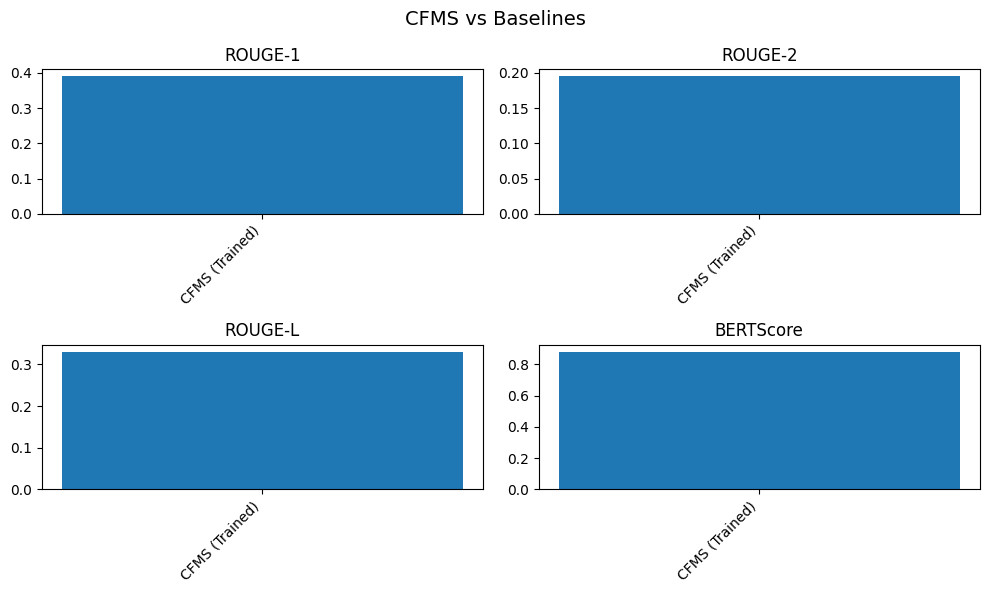

✅ Saved plot: cfms_final_results.png


In [26]:
# ============================================================
# CELL 10: Final Comparison Table + Visualization
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Add your trained CFMS result (if available)
if 'CFMS (Trained)' not in results_table:
    print("⚠️ CFMS trained results not found. Skipping model row.")

# Convert baseline + CFMS results into DataFrame
final_df = pd.DataFrame(results_table).T

# Sort by ROUGE-1
final_df = final_df.sort_values('ROUGE-1', ascending=False)

print("\n" + "="*70)
print(" FINAL MODEL COMPARISON (ROUGE + BERTScore)")
print("="*70)
print(final_df.to_string(float_format="%.4f"))
print("="*70)

# ---------------- PLOT ----------------
metrics = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore"]

plt.figure(figsize=(10, 6))

for i, metric in enumerate(metrics):
    plt.subplot(2, 2, i + 1)
    plt.bar(final_df.index, final_df[metric])
    plt.xticks(rotation=45, ha="right")
    plt.title(metric)
    plt.tight_layout()

plt.suptitle("CFMS vs Baselines", fontsize=14)
plt.tight_layout()
plt.savefig("cfms_final_results.png")
plt.show()

print("✅ Saved plot: cfms_final_results.png")

In [27]:
# ============================================================
# CELL 11: Save Model + Results
# ============================================================

import torch

# Save results table
final_df.to_csv("cfms_results.csv", index=True)
print("✅ Saved: cfms_results.csv")

# Save model weights
torch.save(cfms_model.state_dict(), "cfms_model.pt")
print("✅ Saved: cfms_model.pt")

# Optional: save full training checkpoint (recommended)
checkpoint = {
    "model_state_dict": cfms_model.state_dict(),
    "device": str(device),
    "hidden_size": 768
}

torch.save(checkpoint, "cfms_checkpoint_full.pt")
print("✅ Saved: cfms_checkpoint_full.pt")

print("\n📦 All files saved successfully!")

✅ Saved: cfms_results.csv
✅ Saved: cfms_model.pt
✅ Saved: cfms_checkpoint_full.pt

📦 All files saved successfully!
